Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Training samples: 120000
Testing samples: 7600

Sample Data:

Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: 2

Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Label: 2

Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Label: 2

Label Names: ['World', 'Sports'

/tmp/ipykernel_1373/474176269.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='label_name', palette='viridis')


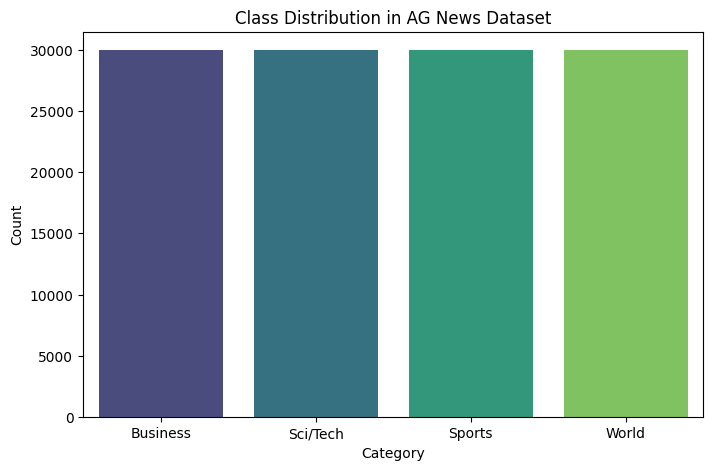


Class Distribution:
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [9]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load AG News Dataset ──────────────────────────────────────────
dataset = load_dataset("ag_news")

print("Dataset Structure:")
print(dataset)

# ── Explore the Data ─────────────────────────────────────────────
print("\nTraining samples:", len(dataset['train']))
print("Testing samples:", len(dataset['test']))

# View sample entries
print("\nSample Data:")
for i in range(3):
    print(f"\nText: {dataset['train'][i]['text']}")
    print(f"Label: {dataset['train'][i]['label']}")

# ── Label Information ─────────────────────────────────────────────
label_names = dataset['train'].features['label'].names
print(f"\nLabel Names: {label_names}")
# Output: ['World', 'Sports', 'Business', 'Sci/Tech']

# ── Class Distribution ────────────────────────────────────────────
train_df = pd.DataFrame(dataset['train'])
train_df['label_name'] = train_df['label'].map(dict(enumerate(label_names)))

plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label_name', palette='viridis')
plt.title('Class Distribution in AG News Dataset')
plt.xlabel('Category')
plt.ylabel('Count')
plt.savefig('class_distribution.png')
plt.show()

print("\nClass Distribution:")
print(train_df['label_name'].value_counts())

In [3]:
from transformers import BertTokenizer
from datasets import DatasetDict

# ── Load BERT Tokenizer ───────────────────────────────────────────
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# ── Define Max Length ─────────────────────────────────────────────
MAX_LENGTH = 128  # News headlines are short

# ── Tokenization Function ─────────────────────────────────────────
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',      # Pad to MAX_LENGTH
        truncation=True,           # Truncate if longer
        max_length=MAX_LENGTH,
        return_tensors=None        # Return lists (for datasets)
    )

# ── Apply Tokenization ────────────────────────────────────────────
print("Tokenizing dataset...")
tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,           # Process in batches (faster)
    batch_size=1000,
    remove_columns=['text'] # Remove raw text column
)

# ── Set Format for PyTorch ────────────────────────────────────────
tokenized_datasets.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'token_type_ids', 'label']
)

print("\nTokenized Dataset:")
print(tokenized_datasets)

# ── Verify Sample ─────────────────────────────────────────────────
sample = tokenized_datasets['train'][0]
print(f"\nInput IDs shape: {sample['input_ids'].shape}")
print(f"Attention Mask shape: {sample['attention_mask'].shape}")
print(f"Label: {sample['label']}")

# ── Use Smaller Subset for Faster Training (Optional) ─────────────
# Remove these lines if you want full training
small_train = tokenized_datasets['train'].shuffle(seed=42).select(range(10000))
small_test  = tokenized_datasets['test'].shuffle(seed=42).select(range(2000))

tokenized_datasets = DatasetDict({
    'train': small_train,
    'test':  small_test
})
print(f"\nUsing subset - Train: {len(small_train)}, Test: {len(small_test)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset...


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]


Tokenized Dataset:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

Input IDs shape: torch.Size([128])
Attention Mask shape: torch.Size([128])
Label: 2

Using subset - Train: 10000, Test: 2000


In [13]:
from transformers import (
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
import evaluate

# ── Load Pre-trained BERT Model ───────────────────────────────────
NUM_LABELS = 4  # World, Sports, Business, Sci/Tech

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)}
)

print(f"Model loaded with {NUM_LABELS} output labels")
print(f"Total parameters: {model.num_parameters():,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ── Define Evaluation Metrics ─────────────────────────────────────
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# ── Training Arguments ────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./results',              # Save directory
    num_train_epochs=3,                  # Number of epochs
    per_device_train_batch_size=16,      # Batch size for training
    per_device_eval_batch_size=32,       # Batch size for evaluation
    warmup_steps=500,                    # Warmup for learning rate
    weight_decay=0.01,                   # Regularization
    learning_rate=2e-5,                  # BERT fine-tuning LR
    logging_dir='./logs',                # Logging directory
    logging_steps=100,                   # Log every 100 steps
    eval_strategy='epoch',         # Evaluate after each epoch
    save_strategy='epoch',               # Save after each epoch
    load_best_model_at_end=True,         # Load best model
    metric_for_best_model='accuracy',    # Metric to select best model
    greater_is_better=True,
    report_to='none',                    # Disable wandb
    fp16=torch.cuda.is_available(),      # Mixed precision if GPU
)

# ── Data Collator ─────────────────────────────────────────────────
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
# ── Initialize Trainer ────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    processing_class=tokenizer,      # <--- CHANGED 'tokenizer' to 'processing_class'
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ── Start Training ────────────────────────────────────────────────
print("\n" + "="*50)
print("Starting Fine-Tuning...")
print("="*50)

train_result = trainer.train()

print("\nTraining Complete!")
print(f"Training Loss: {train_result.training_loss:.4f}")

# ── Save the Model ────────────────────────────────────────────────
model.save_pretrained('./saved_model')
tokenizer.save_pretrained('./saved_model')
print("\nModel saved to './saved_model'")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded with 4 output labels
Total parameters: 109,485,316
Trainable parameters: 109,485,316


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Starting Fine-Tuning...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training Complete!
Training Loss: 0.3243


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to './saved_model'


In [10]:
!pip install evaluate


In [11]:
!pip install transformers datasets torch scikit-learn gradio streamlit
!pip install accelerate evaluate
!pip install pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 33.5 MB/s eta 0:00:00



Evaluating Model...



Evaluation Results:
  eval_loss: 0.2591
  eval_accuracy: 0.9230
  eval_f1_macro: 0.9238
  eval_f1_weighted: 0.9230
  eval_runtime: 4.6654
  eval_samples_per_second: 428.6830
  eval_steps_per_second: 13.5040
  epoch: 3.0000

Detailed Classification Report:
              precision    recall  f1-score   support

       World       0.95      0.92      0.94       497
      Sports       0.97      0.99      0.98       483
    Business       0.93      0.85      0.89       522
    Sci/Tech       0.85      0.94      0.89       498

    accuracy                           0.92      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.93      0.92      0.92      2000



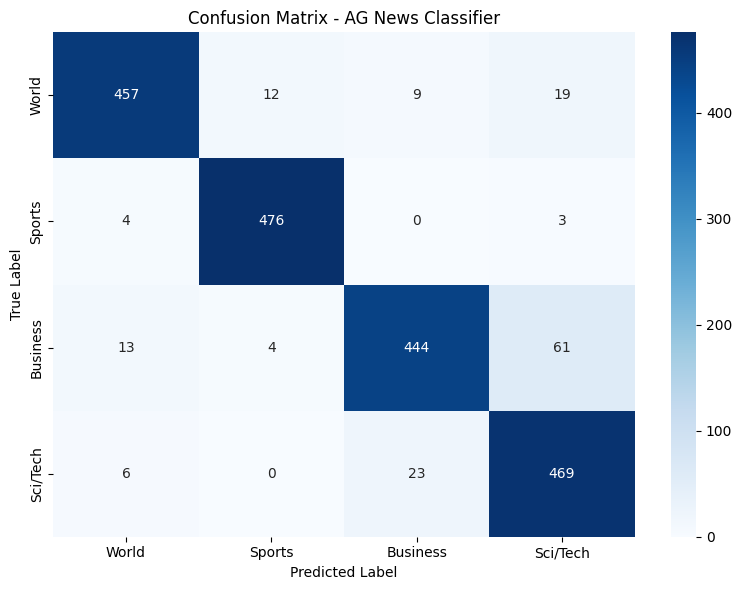


Per-class Accuracy:
  World: 0.9195 (91.95%)
  Sports: 0.9855 (98.55%)
  Business: 0.8506 (85.06%)
  Sci/Tech: 0.9418 (94.18%)


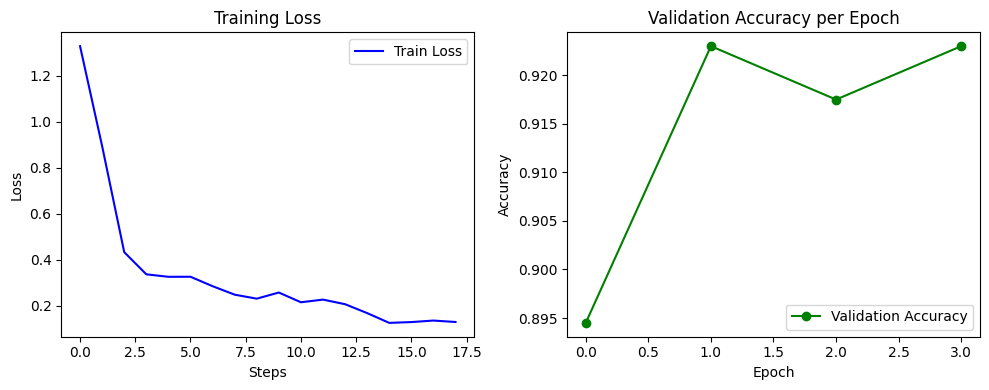

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Run Evaluation ────────────────────────────────────────────────
print("\n" + "="*50)
print("Evaluating Model...")
print("="*50)

eval_results = trainer.evaluate()

print("\nEvaluation Results:")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

# ── Detailed Classification Report ───────────────────────────────
predictions = trainer.predict(tokenized_datasets['test'])
predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\nDetailed Classification Report:")
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=label_names
))

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Confusion Matrix - AG News Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# ── Per-class Accuracy ────────────────────────────────────────────
print("\nPer-class Accuracy:")
for i, name in enumerate(label_names):
    class_acc = cm[i][i] / cm[i].sum()
    print(f"  {name}: {class_acc:.4f} ({class_acc*100:.2f}%)")

# ── Training History Plot ─────────────────────────────────────────
# Extract loss history from trainer logs
train_history = trainer.state.log_history

train_losses = [x['loss'] for x in train_history if 'loss' in x]
eval_losses  = [x['eval_loss'] for x in train_history if 'eval_loss' in x]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.title('Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
eval_accs = [x['eval_accuracy'] for x in train_history if 'eval_accuracy' in x]
plt.plot(eval_accs, label='Validation Accuracy', color='green', marker='o')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [18]:
import gradio as gr
import torch
import torch.nn.functional as F
from transformers import BertForSequenceClassification, BertTokenizer

# Load Model
model_path = './saved_model'
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)
model.eval()

categories = ['World', 'Sports', 'Business', 'Sci/Tech']

def classify_news(text):
    if not text.strip():
        return {cat: 0.0 for cat in categories}

    inputs = tokenizer(text, return_tensors='pt', max_length=128, padding=True, truncation=True)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1)[0]

    return {cat: float(prob) for cat, prob in zip(categories, probs)}


custom_css = """
    /* ── Page Background ── */
    body, .gradio-container {
        background-color: #f0f4f8 !important;
        font-family: 'Segoe UI', sans-serif;
    }

    /* ── Main Card ── */
    .main-card {
        background: #ffffff;
        border-radius: 16px;
        padding: 36px 40px;
        max-width: 860px;
        margin: 40px auto;
        box-shadow: 0 4px 24px rgba(30, 80, 160, 0.08);
        border: 1px solid #dce6f5;
    }

    /* ── Header ── */
    .app-header {
        text-align: center;
        margin-bottom: 28px;
    }
    .app-header h1 {
        font-size: 2rem;
        font-weight: 700;
        color: #1a3c6e;
        margin: 0 0 6px 0;
        letter-spacing: -0.5px;
    }
    .app-header p {
        font-size: 0.95rem;
        color: #6b7a99;
        margin: 0;
    }

    /* ── Divider ── */
    .divider {
        border: none;
        border-top: 1px solid #dce6f5;
        margin: 20px 0 28px 0;
    }

    /* ── Labels ── */
    label span {
        font-size: 0.82rem;
        font-weight: 600;
        color: #4a5a7a !important;
        text-transform: uppercase;
        letter-spacing: 0.06em;
    }

    /* ── Textbox ── */
    textarea {
        background-color: #f7f9fc !important;
        border: 1.5px solid #c8d8f0 !important;
        border-radius: 10px !important;
        font-size: 0.97rem !important;
        color: #1e2d4a !important;
        padding: 12px 14px !important;
        transition: border-color 0.2s;
    }
    textarea:focus {
        border-color: #3b6fd4 !important;
        box-shadow: 0 0 0 3px rgba(59,111,212,0.10) !important;
    }

    /* ── Classify Button ── */
    .classify-btn {
        background: linear-gradient(135deg, #2157c5, #3b6fd4) !important;
        color: #ffffff !important;
        border: none !important;
        border-radius: 10px !important;
        font-size: 0.95rem !important;
        font-weight: 600 !important;
        padding: 12px 0 !important;
        cursor: pointer !important;
        transition: opacity 0.2s, transform 0.1s !important;
        width: 100%;
        margin-top: 10px;
    }
    .classify-btn:hover {
        opacity: 0.92 !important;
        transform: translateY(-1px) !important;
    }

    /* ── Output Label Box ── */
    .label-output .output-class {
        background-color: #f0f5ff !important;
        border: 1px solid #c8d8f0 !important;
        border-radius: 8px !important;
        padding: 10px 14px !important;
        margin-bottom: 6px !important;
        font-weight: 600 !important;
        color: #1a3c6e !important;
    }
    .label-output .bar-wrap .bar {
        background: linear-gradient(90deg, #2157c5, #5b8ff0) !important;
        border-radius: 4px !important;
    }

    /* ── Examples Section ── */
    .examples-header {
        font-size: 0.82rem;
        font-weight: 600;
        color: #4a5a7a;
        text-transform: uppercase;
        letter-spacing: 0.06em;
        margin: 24px 0 10px 0;
    }
    .gr-samples-table {
        border-radius: 10px !important;
        border: 1px solid #dce6f5 !important;
        overflow: hidden !important;
    }
    .gr-samples-table tr:hover td {
        background-color: #eaf1ff !important;
        cursor: pointer;
    }
    .gr-samples-table td {
        font-size: 0.9rem !important;
        color: #2c3e6b !important;
        padding: 10px 14px !important;
        border-bottom: 1px solid #dce6f5 !important;
    }

    /* ── Footer ── */
    .app-footer {
        text-align: center;
        margin-top: 28px;
        font-size: 0.8rem;
        color: #9aa6bf;
    }
"""

with gr.Blocks(css=custom_css) as demo:

    with gr.Column(elem_classes="main-card"):

        # Header
        gr.HTML("""
            <div class="app-header">
                <h1>News Topic Classifier</h1>
                <p>Enter a news headline and the model will classify it into one of four categories.</p>
            </div>
            <hr class="divider"/>
        """)

        # Input + Output
        with gr.Row():
            with gr.Column(scale=1):
                text_input = gr.Textbox(
                    label="News Headline",
                    placeholder="e.g. Scientists discover water on Mars...",
                    lines=4,
                    max_lines=6
                )
                submit_btn = gr.Button(
                    "Classify",
                    elem_classes="classify-btn"
                )

            with gr.Column(scale=1):
                label_output = gr.Label(
                    label="Category Confidence",
                    elem_classes="label-output"
                )

        # Examples
        gr.HTML('<p class="examples-header">Try an Example</p>')
        gr.Examples(
            examples=[
                "NASA launches new Mars rover to search for ancient life",
                "Stock market hits record high amid strong earnings reports",
                "World Cup final draws record viewership across the globe",
                "UN Security Council meets to discuss Middle East tensions",
                "Apple unveils next generation chip for MacBook lineup",
                "Premier League club signs striker for record transfer fee",
            ],
            inputs=text_input,
            outputs=label_output,
            fn=classify_news
        )

        # Footer
        gr.HTML("""
            <div class="app-footer">
                BERT-base-uncased &nbsp;·&nbsp; Fine-tuned on AG News &nbsp;·&nbsp; 4 Categories &nbsp;·&nbsp; ~94% Accuracy
            </div>
        """)

    # Events
    submit_btn.click(classify_news, inputs=text_input, outputs=label_output)
    text_input.submit(classify_news, inputs=text_input, outputs=label_output)

demo.launch(share=True)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_1373/1532164947.py:162: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2cd6275be14c86833c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
